# DataPre-Processing & Feature Selection

## Importing Lib

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

## Data Loading 

In [2]:
df=pd.read_csv("female_players_20.csv")
pd.set_option("display.max_columns",None)

In [3]:
df.replace('[!@#\?]','',regex=True,inplace=True)

In [4]:
columns = ['ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam', 'ram', 'lm', 'lcm', 'cm', 'rcm','rm', 'lwb', 'ldm', 'cdm', 'rdm', 
           'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb','gk']
df[columns]
for colmun in columns:
    df[colmun] = df[colmun].str.split('+',expand=True)[0]

## Data Preprocessing

### 1. Handle Missing Values

In [5]:
pd.set_option('display.max_rows',None)
df.isnull().sum()

sofifa_id                        0
player_url                       0
short_name                       0
long_name                        0
player_positions                 0
overall                          0
potential                        0
value_eur                      345
wage_eur                       345
age                              0
dob                              0
height_cm                        0
weight_kg                        0
club_team_id                   345
club_name                      345
league_name                    345
league_level                   345
club_position                  345
club_jersey_number             345
club_loaned_from               345
club_joined                    345
club_contract_valid_until      345
nationality_id                   0
nationality_name                 0
nation_team_id                   0
nation_position                  0
nation_jersey_number             0
preferred_foot                   0
weak_foot           

In [6]:
columns_to_impute = ['release_clause_eur','club_contract_valid_until', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

for column in columns_to_impute:
    median_value = df[column].median()
    df[column].fillna(median_value, inplace=True)

In [7]:
for column in columns_to_impute:
    missing_count = df[column].isnull().sum()
    print(f"{column}: {missing_count}")

release_clause_eur: 345
club_contract_valid_until: 345
pace: 0
shooting: 0
passing: 0
dribbling: 0
defending: 0
physic: 0


### 2. Handle Outliers

In [8]:
num_df=df.select_dtypes(include=["int64","float64"])
num_df.columns

Index(['sofifa_id', 'overall', 'potential', 'value_eur', 'wage_eur', 'age',
       'height_cm', 'weight_kg', 'club_team_id', 'club_name', 'league_name',
       'league_level', 'club_position', 'club_jersey_number',
       'club_loaned_from', 'club_joined', 'club_contract_valid_until',
       'nationality_id', 'nation_team_id', 'nation_jersey_number', 'weak_foot',
       'skill_moves', 'international_reputation', 'release_clause_eur', 'pace',
       'shooting', 'passing', 'dribbling', 'defending', 'physic',
       'attacking_crossing', 'attacking_finishing',
       'attacking_heading_accuracy', 'attacking_short_passing',
       'attacking_volleys', 'skill_dribbling', 'skill_curve',
       'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
       'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
       'movement_reactions', 'movement_balance', 'power_shot_power',
       'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
       'menta

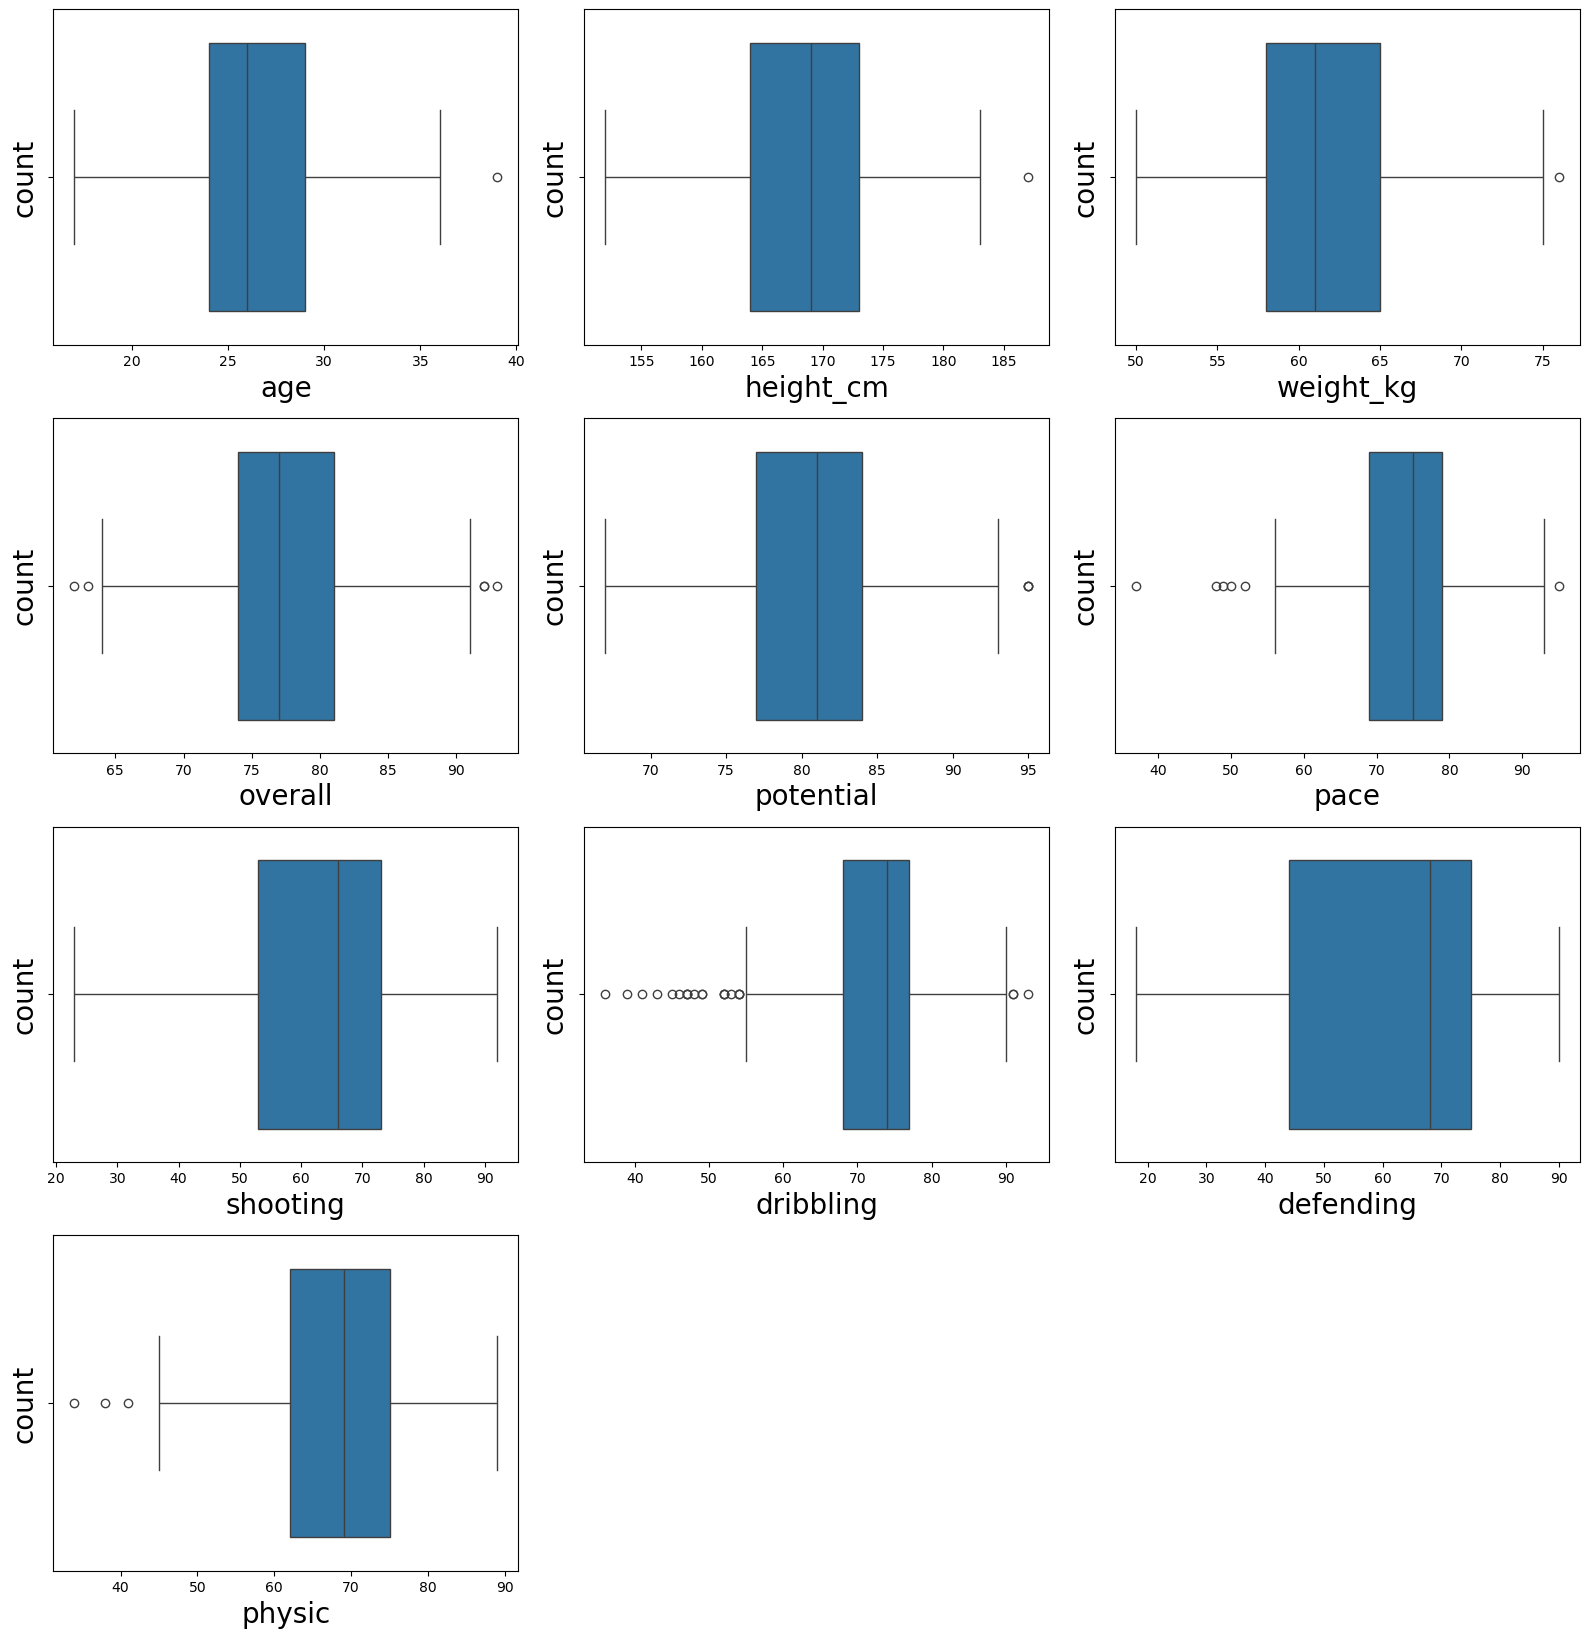

In [9]:
outlier_check = ['age', 'height_cm', 'weight_kg', 'overall', 'potential', 'pace',
                 'shooting', 'dribbling', 'defending', 'physic']
for col in ['value_eur', 'wage_eur', 'release_clause_eur']:
    df[col] = df[col].fillna(0)  # Or use df[col].median() if you have partial data elsewhere
def plot_outliers_safely(df, columns):
    plt.figure(figsize=(16, 20))
    plot_number = 1
    for column in columns:
        if column in df.columns and pd.api.types.is_numeric_dtype(df[column]):
            data = df[column].dropna()
            if len(data) < 2 or data.var() == 0:
                continue
            ax = plt.subplot(5, 3, plot_number) 
            sns.boxplot(x=data, ax=ax)
            plt.xlabel(column, fontsize=20)
            plt.ylabel("count", fontsize=20)
            plot_number += 1        
    plt.tight_layout() 
plot_outliers_safely(df, outlier_check)

In [10]:
# Age
Q1=df["age"].quantile(0.25)
Q3=df["age"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [11]:
df.loc[df["age"]>upper_limit]
len(df.loc[df["age"]>upper_limit])/len(df)
df.loc[df["age"]>upper_limit,"age"]=df["age"].median()

In [12]:
df.loc[df["age"]<lower_limit]

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined,club_contract_valid_until,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url


In [13]:
# Height
Q1=df["height_cm"].quantile(0.25)
Q3=df["height_cm"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [14]:
df.loc[df["height_cm"]>upper_limit]
len(df.loc[df["height_cm"]>upper_limit])/len(df)
df.loc[df["height_cm"]>upper_limit,"height_cm"]=df["height_cm"].median()

In [15]:
df.loc[df["height_cm"]<lower_limit]

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined,club_contract_valid_until,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url


In [16]:
# Weight
Q1=df["weight_kg"].quantile(0.25)
Q3=df["weight_kg"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [17]:
df.loc[df["weight_kg"]>upper_limit]
len(df.loc[df["weight_kg"]>upper_limit])/len(df)
df.loc[df["weight_kg"]>upper_limit,"weight_kg"]=df["weight_kg"].median()

In [18]:
df.loc[df["weight_kg"]<lower_limit]

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined,club_contract_valid_until,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url


In [19]:
# Overall
lower_limit=df["overall"].mean()-3*df["overall"].std()
upper_limit=df["overall"].mean()+3*df["overall"].std()

In [20]:
df.loc[df["overall"]>upper_limit]
len(df.loc[df["overall"]>upper_limit])/len(df)
df.loc[df["overall"]>upper_limit,"overall"]=df["overall"].median()

In [21]:
df.loc[df["overall"]<lower_limit]

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined,club_contract_valid_until,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url


In [22]:
# Potential
Q1=df["potential"].quantile(0.25)
Q3=df["potential"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [23]:
df.loc[df["potential"]>upper_limit]
len(df.loc[df["potential"]>upper_limit])/len(df)
df.loc[df["potential"]>upper_limit,"potential"]=df["potential"].median()

In [24]:
df.loc[df["potential"]<lower_limit]

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined,club_contract_valid_until,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url


In [25]:
# Pace
Q1=df["pace"].quantile(0.25)
Q3=df["pace"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [26]:
df.loc[df["pace"]>upper_limit,"pace"]=df["pace"].median()

In [27]:
df.loc[df["pace"]<lower_limit,"pace"]=df["pace"].median()

In [28]:
# Shooting
# nothing required

In [29]:
# Dribbling
Q1=df["dribbling"].quantile(0.25)
Q3=df["dribbling"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [30]:
df.loc[df["dribbling"]>upper_limit,"dribbling"]=df["dribbling"].median()

In [31]:
df.loc[df["dribbling"]<lower_limit,"dribbling"]=df["dribbling"].median()

In [32]:
# defending 
# nothing required

In [33]:
# Physic
Q1=df["physic"].quantile(0.25)
Q3=df["physic"].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR

In [34]:
df.loc[df["physic"]>upper_limit,"physic"]=df["physic"].median()

In [35]:
df.loc[df["physic"]<lower_limit,"physic"]=df["physic"].median()

### 3. Scaling

In [36]:
scaler = MinMaxScaler() # Object Creation
df[['age','height_cm','weight_kg','overall','potential','value_eur','wage_eur','release_clause_eur','pace','shooting','passing','dribbling','defending','physic','attacking_crossing','attacking_crossing',
    'attacking_finishing','attacking_heading_accuracy','attacking_short_passing','attacking_volleys','skill_dribbling','skill_curve','skill_fk_accuracy','skill_fk_accuracy','skill_long_passing',
    'skill_ball_control','skill_ball_control','movement_acceleration','movement_sprint_speed','movement_agility','movement_reactions','movement_balance','power_shot_power','power_jumping',
    'power_stamina','power_strength','power_long_shots','mentality_aggression','mentality_interceptions','mentality_positioning','mentality_vision','mentality_penalties','mentality_composure',
    'defending_standing_tackle','defending_sliding_tackle','goalkeeping_diving','goalkeeping_handling','goalkeeping_kicking','goalkeeping_positioning',
    'goalkeeping_reflexes']]=scaler.fit_transform(df[['age','height_cm','weight_kg','overall','potential','value_eur','wage_eur','release_clause_eur','pace','shooting','passing','dribbling','defending',
                'physic','attacking_crossing','attacking_crossing','attacking_finishing','attacking_heading_accuracy','attacking_short_passing','attacking_volleys','skill_dribbling','skill_curve','skill_fk_accuracy',
                'skill_fk_accuracy','skill_long_passing','skill_ball_control','skill_ball_control','movement_acceleration','movement_sprint_speed','movement_agility','movement_reactions','movement_balance',
                'power_shot_power','power_jumping','power_stamina','power_strength','power_long_shots','mentality_aggression','mentality_interceptions','mentality_positioning','mentality_vision','mentality_penalties',
                'mentality_composure','defending_standing_tackle','defending_sliding_tackle','goalkeeping_diving','goalkeeping_handling','goalkeeping_kicking','goalkeeping_positioning','goalkeeping_reflexes']])

## Feature Selection

In [37]:
# Drop column
df.drop(['sofifa_id','player_url','short_name','long_name','dob','player_positions','body_type','real_face','player_tags','nation_position','nation_jersey_number','player_traits',
          'ls','st','rs','lw','cf','rf','rw','lam','cam','ram','lm','lcm','cm','rcm','rm','lwb','ldm','cdm','rdm','rwb','lb','lcb','cb','rcb','rb','lf','work_rate'],axis=1,inplace=True)

In [38]:
df.head()

,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,club_team_id,club_name,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined,club_contract_valid_until,nationality_id,nationality_name,nation_team_id,preferred_foot,weak_foot,skill_moves,international_reputation,release_clause_eur,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,1.000000,1.000000,0.0,0.0,0.842105,0.580645,0.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95,United States,113009,Right,4,4,5,0.0,0.540541,0.942029,1.000000,0.542857,0.430556,0.545455,1.000000,0.955556,0.785714,1.000000,0.821429,0.989011,1.000000,0.928571,1.000000,0.976471,0.775,0.743590,0.915493,0.872340,0.625000,0.852941,0.700000,0.714286,0.625000,0.964706,0.675325,0.475610,0.944444,1.000000,0.963855,0.976190,46,0.445783,0.4750,0.119048,0.082353,0.103448,0.104651,0.070588,NaN,21,https://cdn.sofifa.com/players/226/328/20_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113009/60.png,https://cdn.sofifa.com/flags/us.png
1,0.967742,0.538462,0.0,0.0,0.421053,0.483871,0.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,195,Australia,112998,Right,4,4,4,0.0,0.810811,0.971014,0.620690,0.971429,0.291667,0.795455,0.764706,1.000000,0.976190,0.792208,0.880952,0.923077,0.792683,0.630952,0.717949,1.000000,0.925,0.858974,0.929577,0.851064,0.777778,1.000000,0.883333,0.909091,0.777778,0.917647,0.779221,0.195122,1.000000,0.607595,0.698795,0.964286,36,0.349398,0.1625,0.023810,0.082353,0.034483,0.127907,0.094118,NaN,20,https://cdn.sofifa.com/players/227/125/20_120.png,NaN,NaN,https://cdn.sofifa.com/teams/112998/60.png,https://cdn.sofifa.com/flags/au.png
2,0.967742,0.961538,0.0,0.0,0.578947,0.548387,0.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18,France,113003,Right,2,2,4,0.0,0.324324,0.681159,0.448276,0.485714,1.000000,1.000000,0.188235,0.722222,1.000000,0.831169,0.428571,0.714286,0.463415,0.571429,0.820513,0.894118,0.675,0.653846,0.478873,0.765957,0.250000,0.897059,1.000000,0.779221,1.000000,0.670588,0.961039,0.951220,0.722222,0.531646,0.602410,0.821429,90,0.987952,0.9750,0.023810,0.105882,0.137931,0.069767,0.117647,NaN,20,https://cdn.sofifa.com/players/227/316/20_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113003/60.png,https://cdn.sofifa.com/flags/fr.png
3,0.935484,0.961538,0.0,0.0,0.526316,0.612903,0.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21,Germany,113004,Right,4,5,4,0.0,0.648649,0.898551,0.948276,0.942857,0.513889,0.704545,0.941176,0.822222,0.607143,0.987013,0.988095,0.923077,1.000000,1.000000,0.871795,0.976471,0.825,0.807692,0.802817,0.893617,0.736111,0.955882,0.450000,0.857143,0.736111,0.988235,0.766234,0.768293,0.855556,0.987342,1.000000,0.928571,51,0.445783,0.5375,0.035714,0.058824,0.114943,0.046512,0.082353,NaN,19,https://cdn.sofifa.com/players/226/308/20_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113004/60.png,https://cdn.sofifa.com/flags/de.png
4,0.935484,0.923077,0.0,0.0,0.631579,0.612903,0.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18,France,113003,Right,3,4,4,0.0,0.486486,0.724638,0.741379,0.685714,0.986111,1.000000,0.635294,0.722222,0.714286,0.935065,0.571429,0.769231,0.597561,0.619048,0.910256,0.929412,0.750,0.717949,0.732394,0.957447,0.527778,0.823529,0.716667,0.961039,0.930556,0.894118,0.987013,0.987805,0.700000,0.848101,0.7

In [39]:
df.corr(numeric_only=True)


,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,club_team_id,club_name,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined,club_contract_valid_until,nationality_id,nation_team_id,weak_foot,skill_moves,international_reputation,release_clause_eur,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,club_logo_url,club_flag_url
overall,1.000000,0.732417,NaN,NaN,0.378216,0.121076,0.109284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.200915,-0.136120,0.267840,0.329918,0.793354,NaN,0.247176,0.364724,0.549987,0.426472,0.157835,0.417414,0.231926,0.240747,0.274301,0.288006,0.307138,0.252229,0.317572,0.334015,0.283306,0.268851,0.176209,0.190585,0.255492,0.744307,0.028104,0.437286,0.287235,0.292064,0.308273,0.313310,0.276654,0.181136,0.261664,0.318070,0.351813,0.506489,0.134304,0.128220,0.092648,0.009360,0.003363,0.002567,0.010094,0.003928,0.480669,NaN,NaN
potential,0.732417,1.000000,NaN,NaN,-0.185190,0.132858,0.063279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.259879,-0.171571,0.183529,0.269797,0.577873,NaN,0.237428,0.286704,0.438431,0.384751,0.088801,0.228439,0.176981,0.217661,0.174629,0.246756,0.253972,0.231486,0.247575,0.234805,0.247893,0.239209,0.191167,0.189682,0.238784,0.459033,0.068995,0.278505,0.174081,0.228406,0.143754,0.235873,0.142675,0.125844,0.209374,0.288971,0.255410,0.373383,0.082749,0.088803,0.060226,-0.005594,-0.010412,-0.006951,-0.001290,-0.009826,0.601351,NaN,NaN
value_eur,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wage_eur,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,0.378216,-0.185190,NaN,NaN,1.000000,0.006066,0.082931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.020908,0.032276,0.057516,-0.002099,0.323000,NaN,-0.085116,0.056088,0.146964,-0.002588,0.175299,0.272272,-0.010731,-0.053695,0.066603,-0.007825,-0.010276,-0.054616,0.017750,0.084483,0.014225,-0.035755,-0.124350,-0.105441,-0.064165,0.350341,-0.082104,0.140937,0.091685,0.015031,0.195567,0.032449,0.185033,0.106160,-0.026945,0.003720,0.092318,0.122040,0.086390,0.067713,0.074481,0.100916,0.085929,0.079570,0.083381,0.087223,0.067727,NaN,NaN
height_cm,0.121076,0.132858,NaN,NaN,0.006066,1.000000,0.693690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.072463,-0.107478,-0.189115,-0.364145,0.101677,NaN,-0.178237,-0.064322,-0.114825,-0.201264,0.204964,0.415714,-0.346028,-0.281932,0.000315,-0.291716,-0.236160,-0.368993,-0.280416,-0.258749,-0.270905,-0.340469,-0.412003,-0.351469,-0.452196,0.072997,-0.600652,-0.108692,0.105002,-0.219910,0.289986,-0.327483,-0.087758,-0.060316,-0.346078,-0.295200,-0.237758,-0.125538,-0.083909,-0.087858,-0.072627,0.340707,0.345893,0.331817,0.351256,0.337698,0.412495,NaN,NaN
weight_kg,0.109284,0.063279,NaN,NaN,0.082931,0.693690,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.113462,-0.054189,-0.136007,-0.378425,0.100198,NaN,-0.224801,-0.101957,-0.178085,-0.210481,0.186280,0.372459,-0.349983,-0.312727,-0.013133,-0.28957

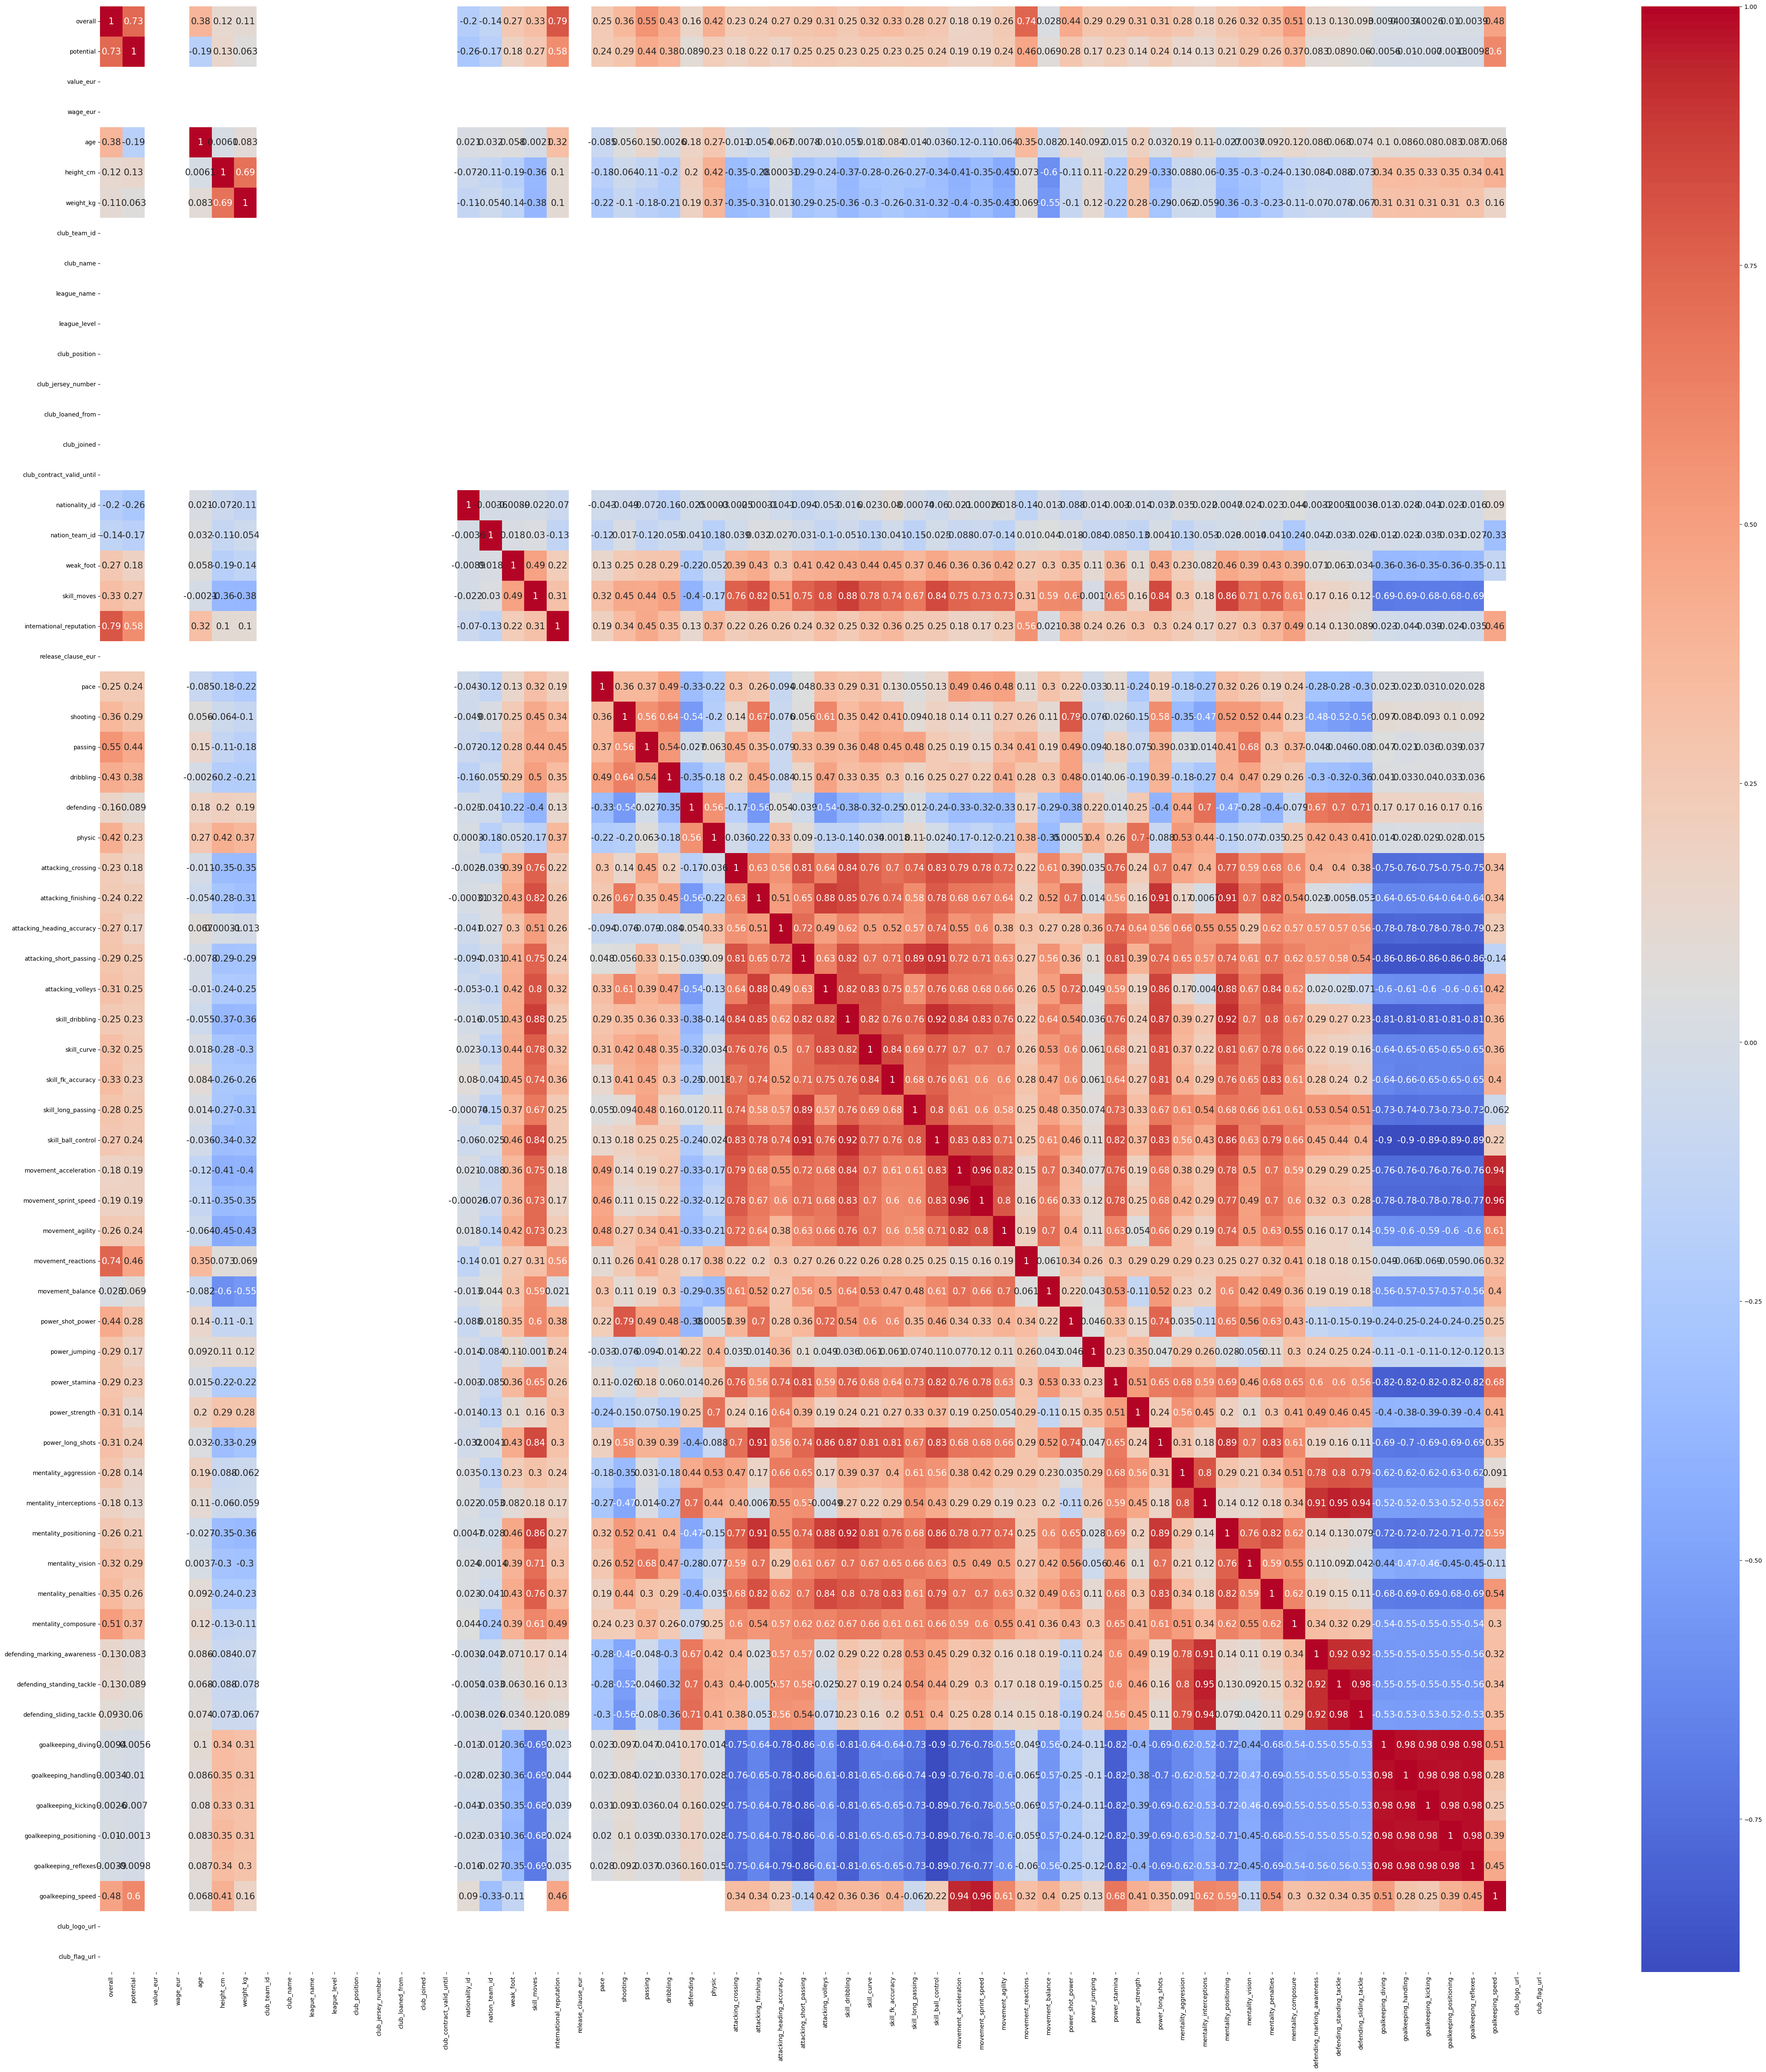

In [40]:
plt.figure(figsize=(55,60))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",annot_kws={"size":15})
plt.show()

In [41]:
pd.set_option('display.max_rows',None)
corrmat = df.corr(numeric_only=True)
corrmat = corrmat.abs().unstack()
corrmat = corrmat.sort_values(ascending=False)
corrmat = corrmat [corrmat >= 0.9]
corrmat = corrmat [corrmat < 1]
corrmat = pd.DataFrame(corrmat).reset_index()
corrmat.columns = ['feature1','feature2','corr']
corrmat

,feature1,feature2,corr
0,goalkeeping_reflexes,goalkeeping_diving,0.984560
1,goalkeeping_diving,goalkeeping_reflexes,0.984560
2,goalkeeping_diving,goalkeeping_positioning,0.981327
3,goalkeeping_positioning,goalkeeping_diving,0.981327
4,goalkeeping_positioning,goalkeeping_reflexes,0.980463
5,goalkeeping_reflexes,goalkeeping_positioning,0.980463
6,goalkeeping_kicking,goalkeeping_reflexes,0.980092
7,goalkeeping_reflexes,goalkeeping_kicking,0.980092
8,goalkeeping_kicking,goalkeeping_handling,0.980035
9,goalkeeping_handling,goalkeeping_kicking,0.980035


In [42]:
df.drop(['defending_standing_tackle','goalkeeping_diving','goalkeeping_handling',
           'goalkeeping_positioning','goalkeeping_reflexes','mentality_interceptions','skill_ball_control',
           'movement_sprint_speed','mentality_positioning','attacking_short_passing'],axis=1,inplace=True)

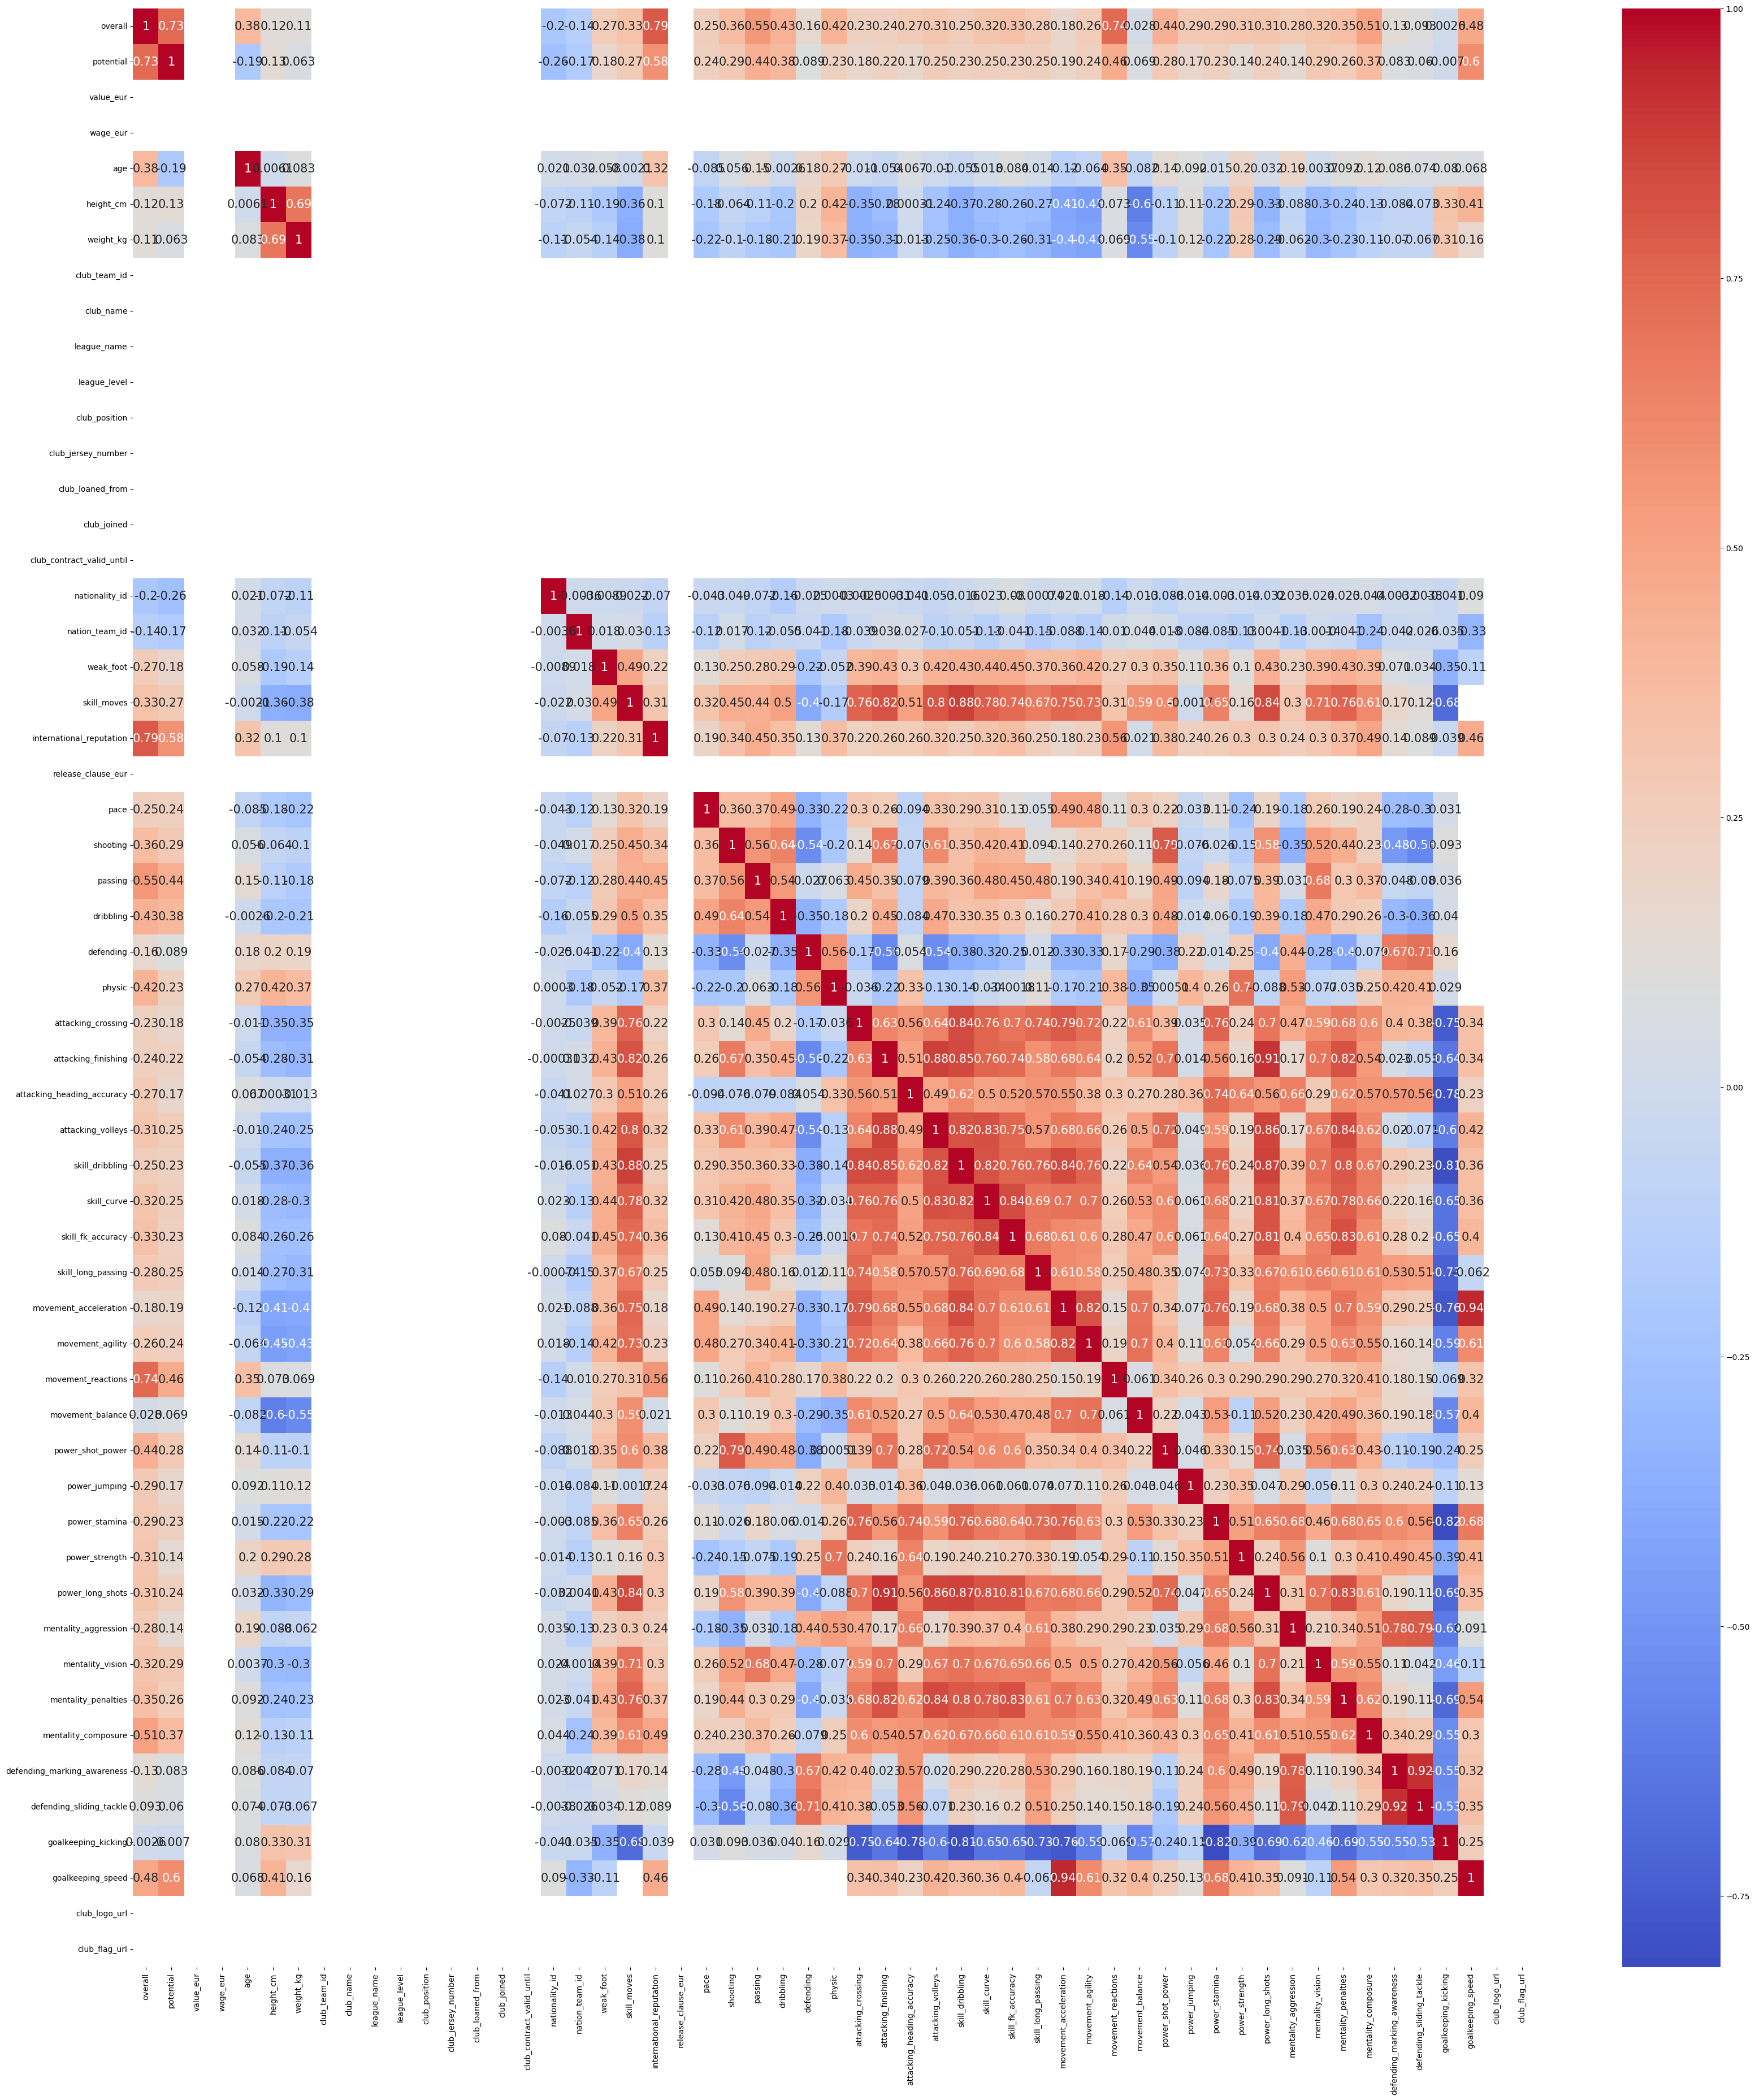

In [43]:
plt.figure(figsize=(40,45))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",annot_kws={"size":15})
plt.show()

In [44]:
df.to_csv('fifa20PreprocessData.csv', index=False)

In [45]:
preprocess_df = pd.read_csv("fifa20PreprocessData.csv")
preprocess_df.head(1)

,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,club_team_id,club_name,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined,club_contract_valid_until,nationality_id,nationality_name,nation_team_id,preferred_foot,weak_foot,skill_moves,international_reputation,release_clause_eur,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,movement_acceleration,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_sliding_tackle,goalkeeping_kicking,goalkeeping_speed,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,1.0,1.0,0.0,0.0,0.842105,0.580645,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95,United States,113009,Right,4,4,5,0.0,0.540541,0.942029,1.0,0.542857,0.430556,0.545455,1.0,0.955556,0.785714,0.821429,0.989011,1.0,0.928571,1.0,0.775,0.915493,0.87234,0.625,0.852941,0.7,0.714286,0.625,0.964706,0.675325,1.0,0.963855,0.97619,46,0.475,0.103448,NaN,21,https://cdn.sofifa.com/players/226/328/20_120.png,NaN,NaN,https://cdn.sofifa.com/teams/113009/60.png,https://cdn.sofifa.com/flags/us.png


In [46]:
df_numeric = df.select_dtypes(include=['int64','float64'])

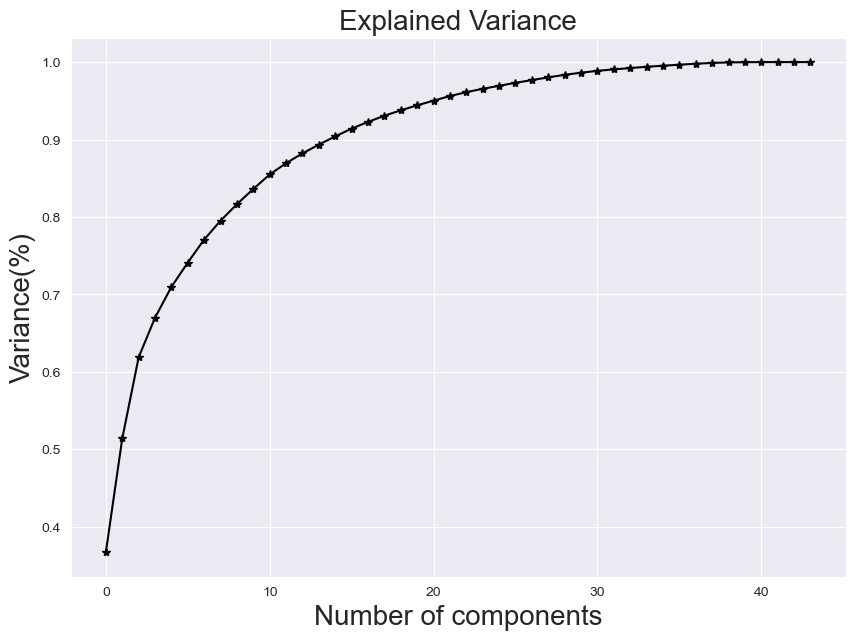

In [47]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

imputer = SimpleImputer(strategy='median')
df_imputed = imputer.fit_transform(df_numeric)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_imputed)
pca = PCA()
principalcomponents = pca.fit_transform(df_scaled)
plt.figure(figsize=(10,7))
sns.set_style('darkgrid')
plt.plot(np.cumsum(pca.explained_variance_ratio_),marker='*',color='k')
plt.xlabel('Number of components',fontsize=20)
plt.ylabel('Variance(%)',fontsize=20)
plt.title('Explained Variance',fontsize=20)
plt.show()

In [48]:
df_numeric = df.select_dtypes(include=np.number).copy()
df_numeric.replace([np.inf, -np.inf], np.nan, inplace=True)
df_numeric.dropna(axis=1, how='all', inplace=True)
df_numeric = df_numeric.apply(lambda x: x.fillna(x.median()), axis=0)

In [49]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)
pca = PCA(n_components=10)
fifa = pca.fit_transform(df_scaled)
pca_df = pd.DataFrame(data=fifa,columns=['pca1','pca2','pca3','pca4','pca5','pca6','pca7','pca8','pca9','pca10'])

In [51]:
pca_df.to_csv('PCA_data.csv', index=False)